# Diagnostics notebook

Loads a combined HDF5 file produced by `write_h5_test_config1.py` or
`write_h5_test_config2.py` and runs the diagnostic plot suite from
`analysis/scripts/plotting.py`.

Set the parameters in the next cell to match the file you want to look
at, then run the whole notebook top-to-bottom.

In [1]:
# Put analysis/scripts on sys.path so the package-less module layout works.
import sys
from pathlib import Path
_REPO_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(_REPO_ROOT / "analysis" / "scripts"))

import numpy as np
import matplotlib.pyplot as plt

import config
from data_loading import load_data
from plotting import plot_diagnostics, plot_linearity

%matplotlib inline

## Parameters

Edit these to point at the file you want to diagnose. The defaults
load the config 1 test file written to `COMBINED_DIR`.

In [6]:
# --- File selection -------------------------------------------------
H5_FILE = config.COMBINED_DIR / "test_config2.h5"   # or .../"test_config2.h5"
CONFIG  = 2                                          # 1 or 2

# --- Reduce data for testing ----------------------------------------
DOWNSAMPLE_N = 20

# --- Train trimming -------------------------------------------------
TRIM_START = 3
TRIM_END   = 3

# --- Hit-counting TOF ranges (ns) -----------------------------------
# Set to None to count every non-zero hit.
E_TOF_RANGE = None
I_TOF_RANGE = None   # ignored for config 2

# --- TOF bin edges for spectra (ns) ---------------------------------
# Defaults reflect the legacy write_h5.py folding parameter (~9969 ns/bunch).
E_TOF_EDGES = np.linspace(0.0, 9969.0, 401)   # 400 bins
I_TOF_EDGES = np.linspace(0.0, 9969.0, 401)   # 400 bins

# --- Linearity binning ----------------------------------------------
# Number of uniform GMD bins for plot_linearity. Set LINEARITY_GMD_EDGES
# to an explicit array to override.
# LINEARITY_N_GMD_BINS = 20
LINEARITY_GMD_EDGES  = np.linspace(0,1.5,21)

# --- Good bunch range (set after inspecting diagnostics) ------------
# Defaults below cover the whole train; set tighter after the first run.
BUNCH_START = 0
BUNCH_END   = None    # filled in below as n_bunches - 1

## Load data

`load_data` filters out trains flagged `between_tdc_files == True` and
trims `TRIM_START` from the head and `TRIM_END` from the tail.

In [7]:
print(f"Loading {H5_FILE} (config {CONFIG})")
data = load_data(str(H5_FILE), config=CONFIG, trim_start=TRIM_START, trim_end=TRIM_END, downsample_N=DOWNSAMPLE_N)

if BUNCH_END is None:
    BUNCH_END = data.n_bunches - 1

print(f"  trains          : {data.n_trains}")
print(f"  bunches/train   : {data.n_bunches}")
print(f"  train ID range  : {int(data.tID.min())} .. {int(data.tID.max())}")
print(f"  gmd     shape   : {data.gmd.shape}")
print(f"  mpe     shape   : {data.mpe.shape}    "
      f"finite={np.isfinite(data.mpe).sum()}/{data.mpe.size}")
print(f"  z       shape   : {data.z.shape}")
if data.tofs_e is not None:
    print(f"  tofs_e  shape   : {data.tofs_e.shape}")
if data.tofs_i is not None:
    print(f"  tofs_i  shape   : {data.tofs_i.shape}")
if data.liq_tofs_e is not None:
    print(f"  liq_tofs_e shape: {data.liq_tofs_e.shape}")
if data.vls is not None:
    print(f"  vls     shape   : {data.vls.shape}")
print(f"  selected bunches: {BUNCH_START}..{BUNCH_END}")

Loading C:\Users\oga17\OneDrive - Imperial College London\Python\glycine2026\11022188\processed\combined\test_config2.h5 (config 2)
vls_moments       : loaded (221, 100)
  crop_roi        : (380, 500)
  background_roi  : (0, 5)
  trains          : 221
  bunches/train   : 100
  train ID range  : 1801575997 .. 1801580913
  gmd     shape   : (221, 100)
  mpe     shape   : (221,)    finite=37/221
  z       shape   : (221, 100)
  liq_tofs_e shape: (221, 100, 50)
  vls     shape   : (221, 100, 1280)
  selected bunches: 0..99


## Diagnostic plots

`plot_diagnostics` returns a 3×3 grid of panels:

1. **Hit-count distribution** — histograms of electron (and ion for config 1) hit counts per shot. Look for a unimodal distribution; a long tail or zero spike suggests a malfunctioning detector or a saturated channel.
2. **Pulse-energy distribution** — should be roughly Gaussian, narrow if the FEL was stable. A bimodal distribution usually means the SASE was hopping between two operating modes.
3. **Bunch index vs GMD** — false-colour 2D histogram. Bands of dark colour at specific bunch indices reveal trains where particular bunches were dropped or attenuated.
4. **GMD vs electron hits** — should be linear; the printed Pearson r tells you how cleanly. A flat curve at high GMD signals detector saturation.
5. **GMD vs ion hits** (config 1) **or average VLS spectrum** (config 2).
6. *(reserved)*
7. **Train ID vs photon energy** — should be flat or stepped (delay scan). Look for OPIS dropouts (NaN gaps).
8. **Train ID vs delay** — should trace out the scan pattern over the run.
9. *(hidden)*

Anything that doesn't match these expectations is worth flagging before you start binning.

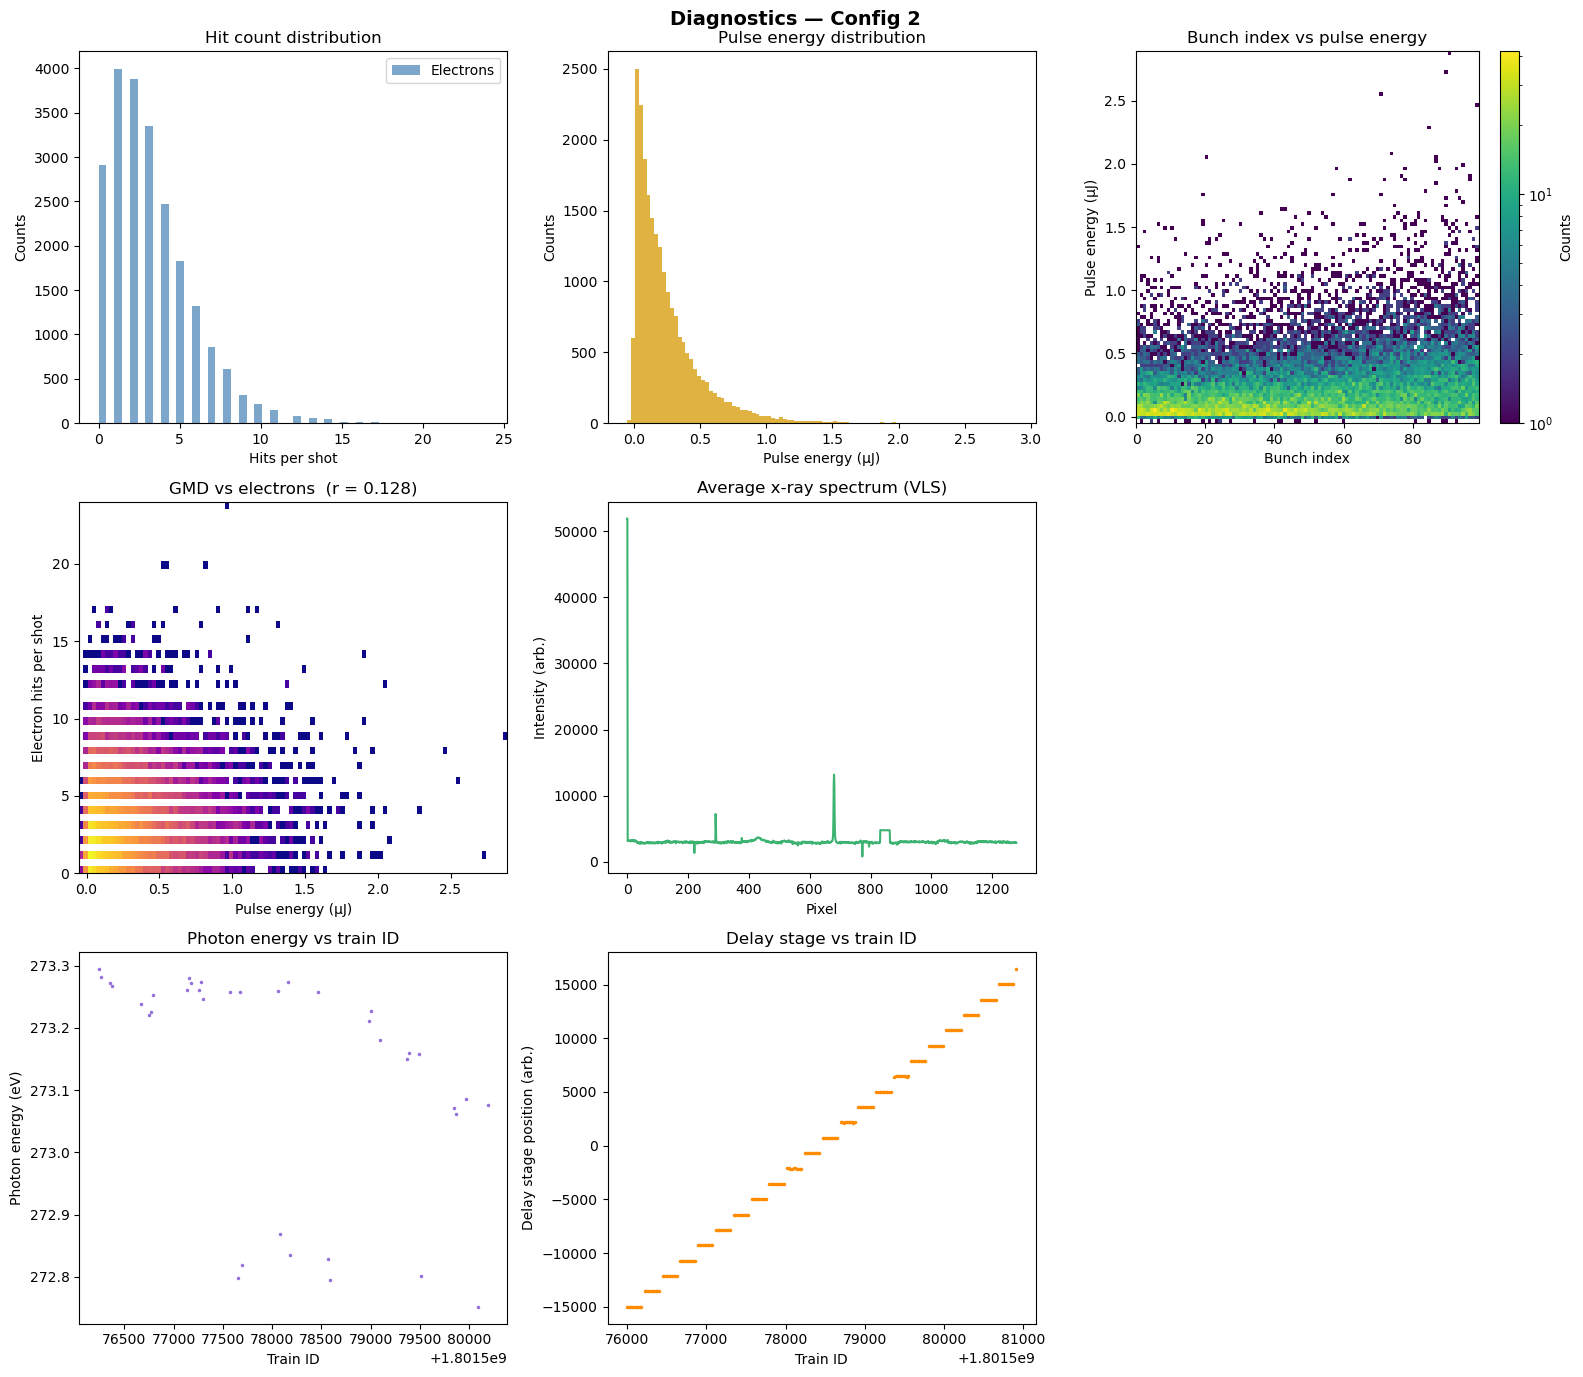

In [8]:
fig, axes = plot_diagnostics(
    data,
    e_tof_edges=E_TOF_EDGES,
    i_tof_edges=I_TOF_EDGES if CONFIG == 1 else None,
    e_tof_range=E_TOF_RANGE,
    i_tof_range=I_TOF_RANGE if CONFIG == 1 else None,
)
plt.show()

## Linearity

`plot_linearity` bins shots by GMD and checks that detector response scales linearly with pulse energy. Always a 2 × 2 grid:

- **Row 1 — electron detector.** Mean electron hits vs mean GMD per bin with a linear fit, then a false-colour bunch-index vs GMD map of the same observable. A clean line through the origin means the detector is in its linear regime; roll-off at high GMD signals saturation, a non-zero intercept usually means dark/background counts, and stripes in the right-hand panel indicate bunch-dependent response.
- **Row 2 — secondary detector.** Config 1: ion TOF hits. Config 2: integrated VLS intensity per shot (summed over the whole pixel axis). Same two panels.

If you tightened `E_TOF_RANGE` / `I_TOF_RANGE` after the diagnostic plot, they propagate through here automatically. `I_TOF_RANGE` is ignored for config 2.

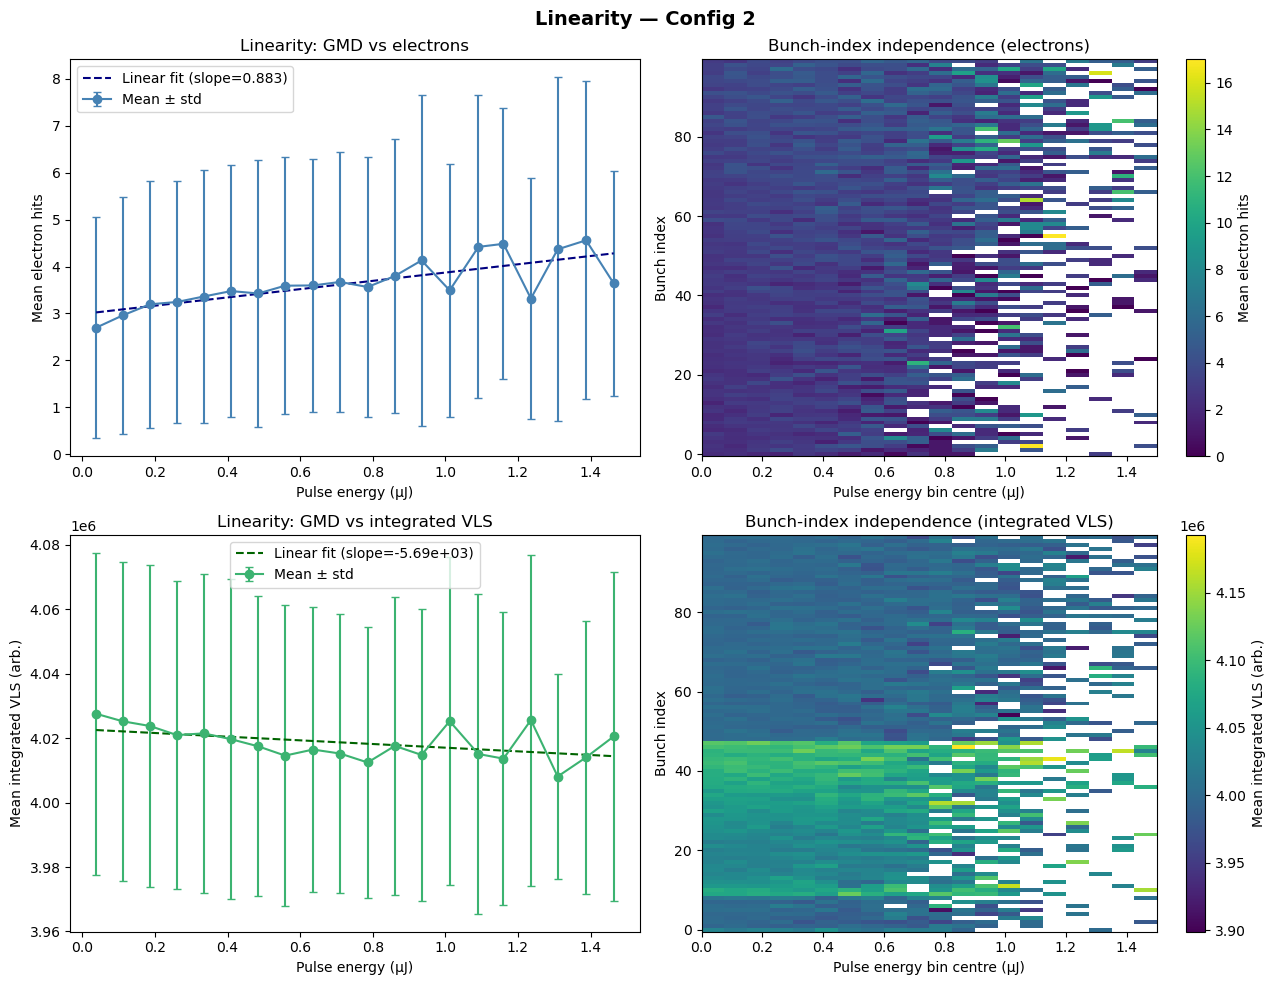

In [9]:
fig, axes = plot_linearity(
    data,
    n_gmd_bins=LINEARITY_N_GMD_BINS,
    gmd_edges=LINEARITY_GMD_EDGES,
    e_tof_range=E_TOF_RANGE,
    i_tof_range=I_TOF_RANGE if CONFIG == 1 else None,
)
plt.show()

## Next steps

Once the diagnostics and linearity plots look reasonable, tighten `E_TOF_RANGE` / `I_TOF_RANGE` to the regions of physical interest, set `BUNCH_START`/`BUNCH_END` to the good range you see in panel 3 of the diagnostics, then move on to `plot_energy_binned_maps` and `plot_delay_dependence`.